Data can be downloaded from https://drive.google.com/drive/folders/1NkwomrirVVgRe2OLMzvg6Qhq4-zcOHfD?usp=sharing 

Place downloaded data folder SCC under ./tutorial/

In [53]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42
import scanpy as sc

In [58]:
# from pyStrint import plotting as pl
# from pyStrint import preprocess as pp
# from pyStrint import evaluation as eva
# import sys
# sys.path.insert(0, '/data6/wangjingwan/5.Simpute/StrInt-main/')
from Strint import plotting as pl
from Strint import preprocess as pp
from Strint import evaluation as eva

In [ ]:
# import importlib
# importlib.reload(eva)
# importlib.reload(pp)
# importlib.reload(pl)

# 0. Load data

In [56]:
spex_inputDir = './tutorial/SCC'
Raw_inputDir = './tutorial/SCC/inputs'
outDir = './tutorial/SCC'

In [55]:
palette_dict = {'Original':'#ef8a62','Refined':'#67a9cf','ST':"#C798EE"}

major_color_map = {'Myeloid':'#EC7063',
 'Endo':'#22a8a1',
 'KC':'#28B463',
 'KC (Cyc)':'#63C1A3',
 'KC (Diff)':'#59BE86',
 'KC (Basal)':'#76D7C4',
 'FB':"#3A84E6",
 'LC':'#3498DB',
 'T cell':'#E88AC2',
 'Epithelial':'#9DB0D4',
 'TSK':'#E74C3C',
 'B cell':'#ffb200',
 'Melanocyte':'#85C1E9',
 'NK':'#C798EE'}

color_map = {'ASDC': '#E74C3C',
 'MDSC':'#F56867',
 'B_Cell': '#D35400',
'B Cell': '#D35400',
 'CD1C': '#EC7063',
 'CD4_Naive': '#DC7633',
 'CD4_Pre_Exh': '#D95F02',
 'CD8_EM': '#ffb200',
 'CD8_Exh': '#ed5eb3',
 'CLEC9A': '#F5B7B1',
 'Eccrine': '#1B9E77',
 'Endothelial_Cell': '#28B463',
  'Endothelial Cell': '#28B463',
 'Fibroblast': '#85C1E9',
 'Keratinocyte': '#58D68D',
 'LC': '#22a8a1',
 'Mac': '#EC7063',
 'Melanocyte': '#2B83BA',
 'Mig_CD1C': '#007FFF',
 'Mig_CLEC9A': '#3498DB',
 'Mig_LC': '#00c9ff',
 'NK': '#8cc63f',
 'PDC': '#9DB0D4',
 'Pilosebaceous': '#5E3C99',
 'TSK': '#EC7063',
 'Treg': '#22a8a1',
 'Tumor_KC_Basal': '#AF7AC5',
 'Tumor_KC_Cyc': '#D2B4DE',
 'Tumor_KC_Diff': '#E88AC2'}

In [ ]:
species = 'Human'
new_exp_fn = f'{spex_inputDir}/alter_sc_exp.tsv'
new_meta_fn = f'{spex_inputDir}/spexmod_sc_meta.tsv'

alter_exp = pd.read_csv(new_exp_fn,sep='\t',index_col=0,header=0)
sc_agg_meta = pd.read_csv(new_meta_fn,sep='\t',index_col=0,header=0)

refine_adata = pp.make_adata(alter_exp,sc_agg_meta,species,save_path = outDir, save_adata = False)
refine_adata.uns['tp_key'] = 'celltype_major'
refine_adata.uns['major_color_map'] = major_color_map
refine_adata.uns['rscript_path'] = '/apps/software/R/4.2.0-foss-2021b/bin/Rscript'
refine_adata.uns['python_path'] = '/apps/software/Anaconda3/2022.05/bin/python'
# del alter_exp

/home/wangjingwan/.local/lib/python3.9/site-packages/anndata/compat/_overloaded_dict.py:106: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  self.data[key] = value


# 1. Overview

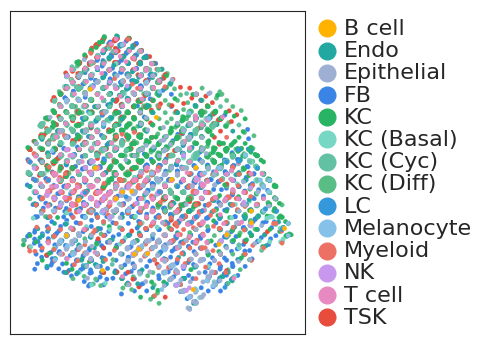

<Figure size 640x480 with 0 Axes>

In [27]:
pl.sc_celltype(refine_adata, color_map = major_color_map,tp_key = 'celltype_major', figsize= (3.8,4.2),
        legend = True, size = 10, alpha = 1, savefig = True)

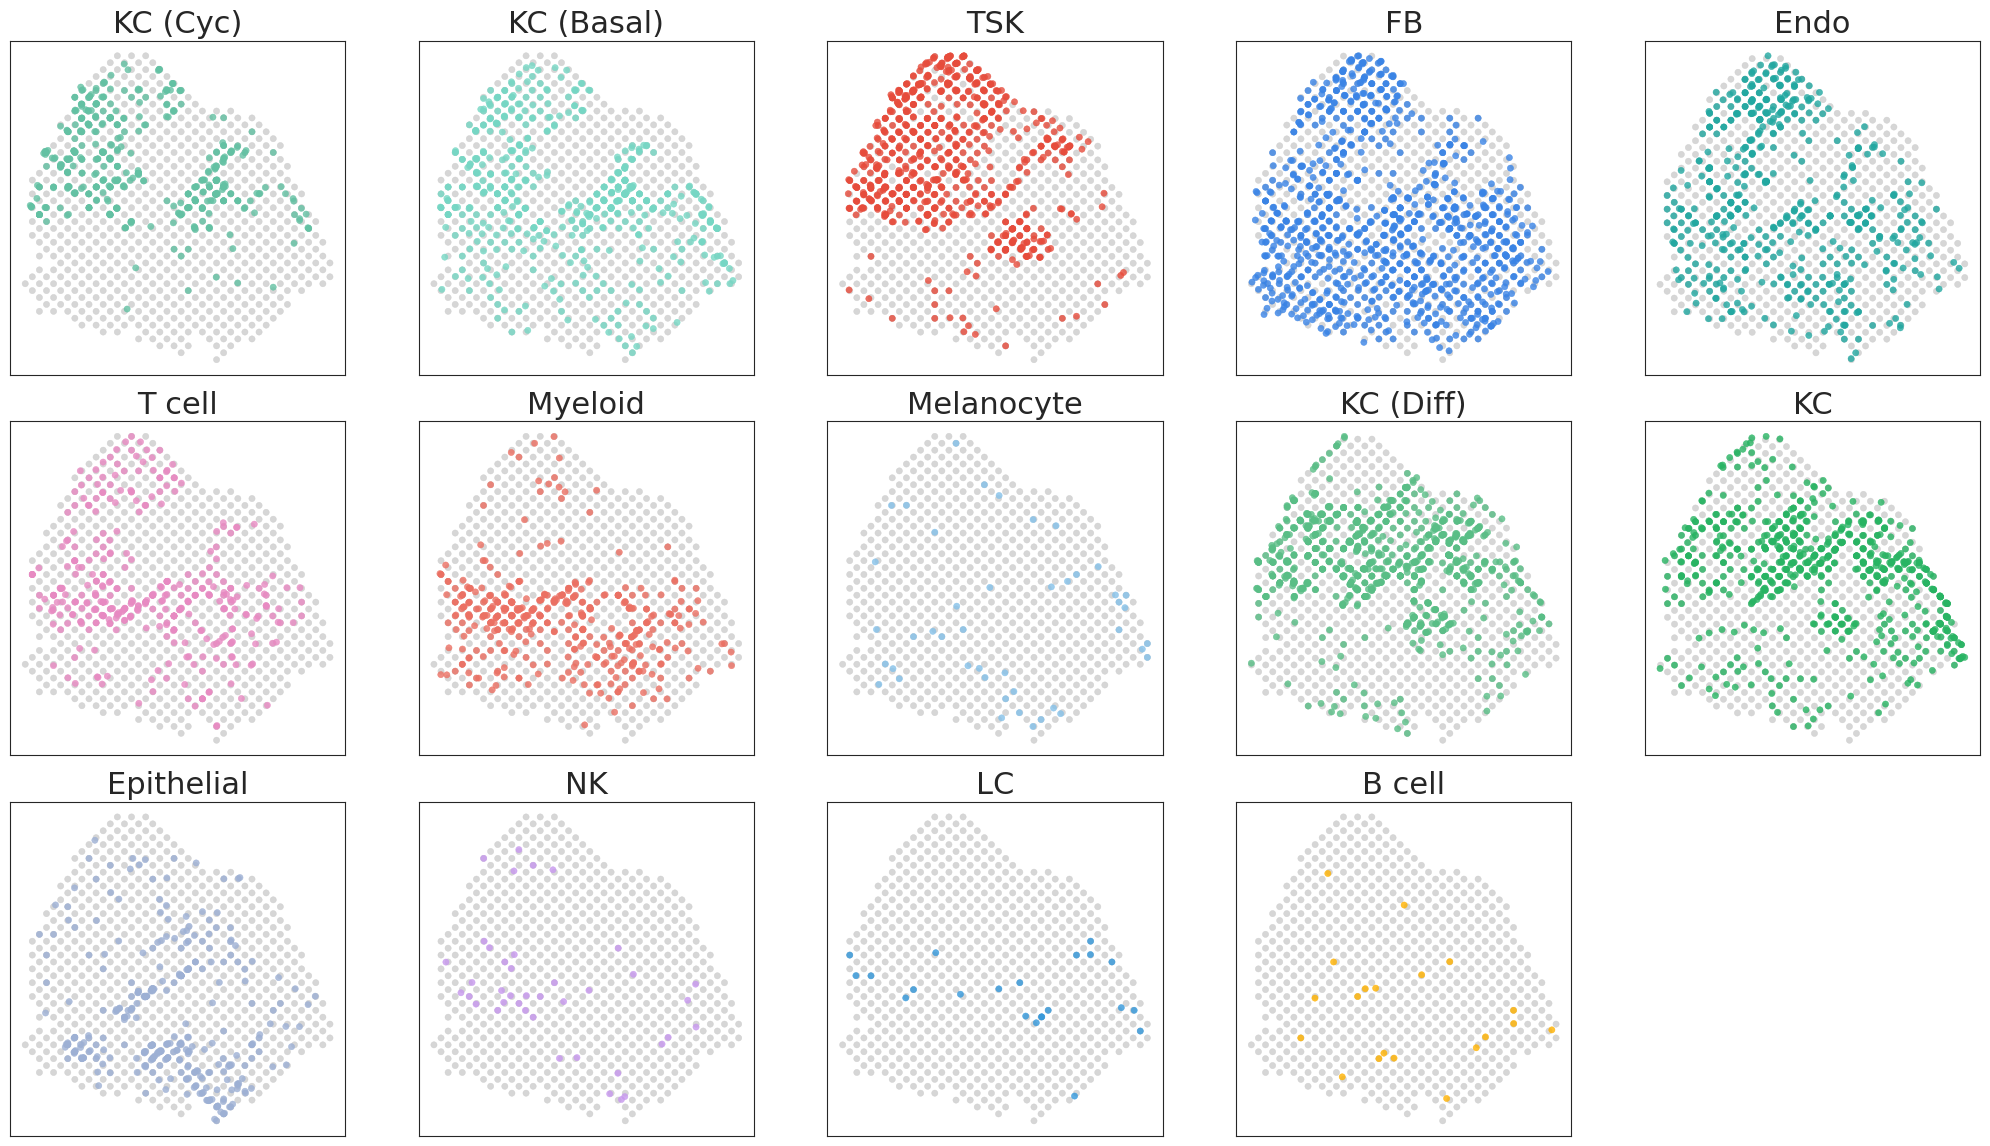

<Figure size 640x480 with 0 Axes>

In [52]:
pl.sc_subtype(refine_adata,color_map = major_color_map,tp_key = 'celltype_major', savefig = True)

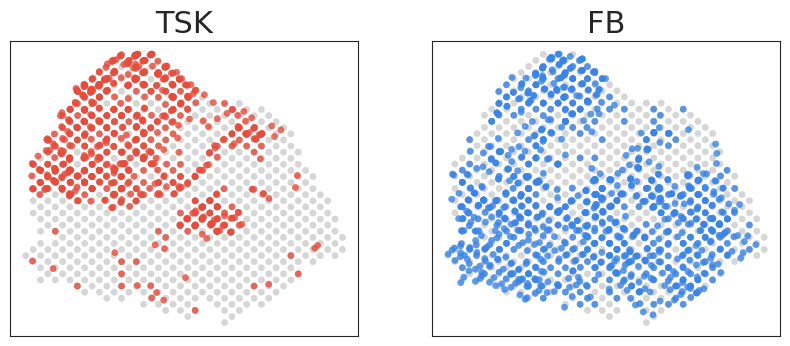

<Figure size 640x480 with 0 Axes>

In [28]:
pl.sc_subtype(refine_adata,color_map = major_color_map,tp_key = 'celltype_major',target_tp = ['TSK','FB'], savefig = True)

# 2. Spot Correlation

In [30]:
refine_spot_cor = eva.runSpotCor(refine_adata, recon_exp_file = new_exp_fn,
                                 recon_meta_file = new_meta_fn,
               orig_sc_file = f'{Raw_inputDir}/SC_exp.tsv', orig_st_file = f'{Raw_inputDir}/ST_exp.tsv')

In [35]:
before_spot_cor = eva.runSpotCor(refine_adata, recon_exp_file = '',
                                 recon_meta_file = new_meta_fn,
               orig_sc_file = f'{Raw_inputDir}/SC_exp.tsv', orig_st_file = f'{Raw_inputDir}/ST_exp.tsv')

Pull cells from original sc_exp


In [38]:
refine_spot_cor.mean()

cor    0.669507
dtype: float64

In [37]:
before_spot_cor.mean()

cor    0.641933
dtype: float64

In [39]:
before_spot_cor['Method'] = 'Original'
refine_spot_cor['Method'] = 'Refined'
spot_cor = pd.concat([before_spot_cor,refine_spot_cor])

p-value annotation legend:
      ns: 5.00e-02 < p <= 1.00e+00
       *: 1.00e-02 < p <= 5.00e-02
      **: 1.00e-03 < p <= 1.00e-02
     ***: 1.00e-04 < p <= 1.00e-03
    ****: p <= 1.00e-04

Original vs. Refined: t-test independent samples with Benjamini-Hochberg correction, P_val:4.905e-08 t=-5.486e+00


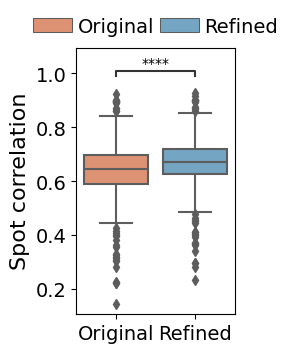

In [51]:
pl.boxplot(spot_cor,palette_dict = palette_dict,
                x='Method', y='cor', hue='Method', ylabel='Spot correlation', legend = True,
                test = 't-test_ind',figsize=(2.4,3.4),savefig = refine_adata.uns['save_path'] + 'spot_cor.pdf')

# 3. SpaTalk

Before executing the code below, ensure that the SpaTalk R library is installed.  
You can find the installation instructions at [https://github.com/ZJUFanLab/SpaTalk](https://github.com/ZJUFanLab/SpaTalk).

In [52]:
# SpaTalk is time cosuming, so we normally run with, using the output at ./SCC/spatalk to proceed
# meta_key is the column that used for spaTalk. 
# Here I want the spatalk result to be more detailed, so I use 'celltype' as meta_key.
# The spatalk result will then be combined with the tp_key.
eva.runSpaTalk(refine_adata, rscript_executable = '/apps/software/R/4.2.0-foss-2021b/bin/Rscript',
               tp_key = 'celltype_major', meta_key = 'celltype', st_dir= new_exp_fn, st_meta_dir= new_meta_fn)

In [48]:
draw_rec,draw_send = eva.generate_cci(refine_adata, return_df = True)

In [49]:
sender_order = ['B cell','T cell','Myeloid','Melanocyte','NK',
                'TSK', 'KC', 'KC (Basal)', 'KC (Cyc)', 'KC (Diff)',
                'FB', 'Endo', 'Epithelial','LC']

4 6


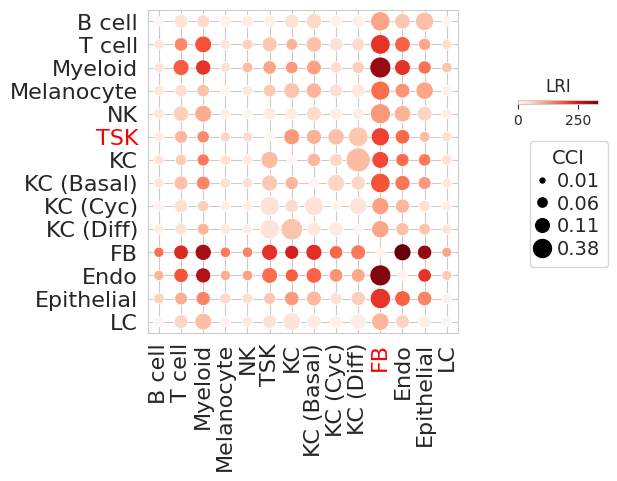

<Figure size 640x480 with 0 Axes>

In [50]:
pl.celltype_cci(refine_adata, is_sender_per = True, figsize = (4,6), 
            target_sender = sender_order, target_receiver = sender_order,
             y_highlight=['TSK'], x_highlight=['FB'],
                cmap = 'Reds', size = 'CCI',hue = 'LRI',
                savefig = True,color_bar_pos = [1.05, 0.38, 0.2, 0.35])

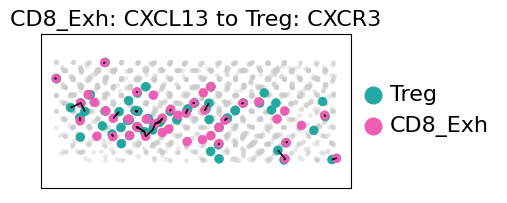

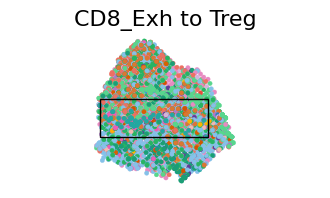

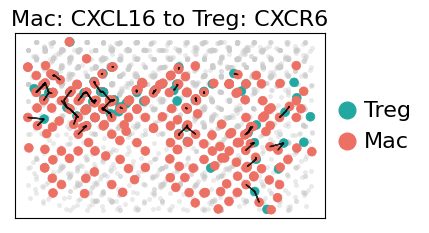

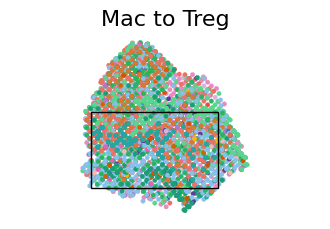

In [53]:
refine_adata.uns['cellpair'][['sender_tp', 'receiver_tp']] = refine_adata.uns['cellpair']['Name'].str.split(' -- ',expand = True)

sender = 'CD8_Exh'
receiver = 'Treg'
ligand = 'CXCL13'
receptor = 'CXCR3'
target_cellpair1 = pl.LRI_of_CCI(refine_adata,sender = sender,receiver = receiver,ligand = ligand,receptor = receptor,hue = 'celltype',
                                color_map = color_map,figsize=(4,2),arrow_length = 0.2, size = 40)

sender = 'Mac'
receiver = 'Treg'
ligand = 'CXCL16'
receptor = 'CXCR6'
target_cellpair1 = pl.LRI_of_CCI(refine_adata,sender = sender,receiver = receiver,ligand = ligand,receptor = receptor,hue = 'celltype',
                                color_map = color_map,figsize=(4,2.4),arrow_length = 0.2, size = 40)